In [4]:
# ── CELL 1: INSTALL & IMPORTS ──────────────────────────────
# Run this once if needed: pip install yfinance pandas numpy matplotlib seaborn scipy

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [5]:

# ── CELL 2: CONFIGURATION ──────────────────────────────────
# Stock universe: large-cap US stocks with consistent earnings history
TICKERS = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META',
    'JPM',  'BAC',  'GS',   'MS',   'WFC',
    'JNJ',  'PFE',  'MRK',  'UNH',  'ABBV',
    'XOM',  'CVX',  'COP',  'SLB',  'EOG',
    'WMT',  'TGT',  'COST', 'HD',   'LOW'
]

MARKET_TICKER  = 'SPY'    # S&P 500 ETF as market benchmark
HOLD_DAYS      = 60       # Days to hold after earnings (PEAD window)
START_DATE     = '2019-01-01'
END_DATE       = '2024-12-31'
TOP_QUANTILE   = 0.20     # Top 20% = long portfolio
BOT_QUANTILE   = 0.20     # Bottom 20% = short portfolio

print(f"Analysing {len(TICKERS)} stocks | Hold period: {HOLD_DAYS} days")

Analysing 25 stocks | Hold period: 60 days


In [6]:
# ── CELL 3: DOWNLOAD PRICE DATA ────────────────────────────
# Theory: We need daily price data to calculate returns.
# yfinance fetches OHLCV data from Yahoo Finance for free.
# We use Adjusted Close to account for dividends and splits.

print("Downloading price data... (this may take 1-2 minutes)")

all_tickers = TICKERS + [MARKET_TICKER]
raw = yf.download(all_tickers, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)

prices = raw['Close'].copy()
prices.dropna(how='all', inplace=True)

# Daily returns: (P_t - P_{t-1}) / P_{t-1}
returns = prices.pct_change().dropna()

market_returns = returns[MARKET_TICKER].copy()
stock_returns  = returns[TICKERS].copy()


print(f"Price data shape: {prices.shape}")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")

Price data shape: (1509, 26)
Date range: 2019-01-02 to 2024-12-30


In [7]:
# ── CELL 4: DOWNLOAD EARNINGS DATA ─────────────────────────
# Theory: yfinance provides EPS estimates vs actuals via
# ticker.get_earnings_dates(). We loop through each ticker
# and collect earnings date, actual EPS, and estimated EPS.

print("\nDownloading earnings data for all tickers...")

all_earnings = []


for ticker in TICKERS:
    try:
        t = yf.Ticker(ticker)
        ed = t.get_earnings_dates(limit=40)  # last ~10 years of quarterly data

        if ed is None or ed.empty:
            continue

        ed = ed.reset_index()
        ed.columns = [c.strip() for c in ed.columns]

        # Rename columns to standard names
        col_map = {}
        for c in ed.columns:
            cl = c.lower()
            if 'earnings' in cl and 'date' in cl:
                col_map[c] = 'date'
            elif 'eps estimate' in cl or 'estimated' in cl:
                col_map[c] = 'eps_estimate'
            elif 'reported' in cl or 'actual' in cl:
                col_map[c] = 'eps_actual'
            elif 'surprise' in cl and '%' in cl:
                col_map[c] = 'surprise_pct'

        ed.rename(columns=col_map, inplace=True)

        required = ['date', 'eps_estimate', 'eps_actual']
        if not all(c in ed.columns for c in required):
            continue

        ed['ticker']  = ticker
        ed['date']    = pd.to_datetime(ed['date']).dt.tz_localize(None).dt.normalize()

        # Filter to our date range and only past (reported) earnings
        ed = ed[
            (ed['date'] >= START_DATE) &
            (ed['date'] <= END_DATE)   &
            (ed['eps_actual'].notna()) &
            (ed['eps_estimate'].notna())
        ]

        all_earnings.append(ed[['ticker', 'date', 'eps_estimate', 'eps_actual']])

    except Exception as e:
        pass

earnings_df = pd.concat(all_earnings, ignore_index=True)
earnings_df.sort_values(['ticker', 'date'], inplace=True)
earnings_df.reset_index(drop=True, inplace=True)


print(f"Total earnings events collected: {len(earnings_df)}")
print(earnings_df.head(10))



Total earnings events collected: 600
  ticker       date  eps_estimate  eps_actual
0   AAPL 2019-01-29          1.04        1.05
1   AAPL 2019-04-30          0.59        0.62
2   AAPL 2019-07-30          0.53        0.55
3   AAPL 2019-10-30          0.71        0.76
4   AAPL 2020-01-28          1.13        1.25
5   AAPL 2020-04-30          0.56        0.64
6   AAPL 2020-07-30          0.52        0.65
7   AAPL 2020-10-29          0.70        0.73
8   AAPL 2021-01-27          1.42        1.68
9   AAPL 2021-04-28          0.98        1.40


In [8]:

# ── CELL 5: CALCULATE EARNINGS SURPRISE ────────────────────
# Theory:
# Surprise % = (Actual - Estimate) / |Estimate| × 100
# This tells us by what percentage the company beat or missed.
# We use absolute value of estimate in denominator so that
# negative estimate companies are handled correctly.

def calc_surprise(actual, estimate):
    """Returns earnings surprise as a percentage."""
    if estimate == 0 or pd.isna(estimate) or pd.isna(actual):
        return np.nan
    return (actual - estimate) / abs(estimate) * 100

earnings_df['surprise_pct'] = earnings_df.apply(
    lambda row: calc_surprise(row['eps_actual'], row['eps_estimate']),
    axis=1
)

# Remove extreme outliers (>500% surprise are usually data errors)
earnings_df = earnings_df[earnings_df['surprise_pct'].abs() <= 500]
earnings_df.dropna(subset=['surprise_pct'], inplace=True)


print(f"\nEarnings surprise stats:")
print(earnings_df['surprise_pct'].describe().round(2))

# What % of events were beats vs misses?
beats  = (earnings_df['surprise_pct'] > 0).sum()
misses = (earnings_df['surprise_pct'] < 0).sum()
inline = (earnings_df['surprise_pct'] == 0).sum()
total  = len(earnings_df)
print(f"\nBeats:  {beats} ({beats/total*100:.1f}%)")
print(f"Misses: {misses} ({misses/total*100:.1f}%)")
print(f"Inline: {inline} ({inline/total*100:.1f}%)")




Earnings surprise stats:
count    596.00
mean       7.77
std       35.73
min     -500.00
25%        1.13
50%        6.08
75%       14.31
max      164.71
Name: surprise_pct, dtype: float64

Beats:  472 (79.2%)
Misses: 110 (18.5%)
Inline: 14 (2.3%)


In [9]:
# ── CELL 6: CALCULATE SUE (Standardized Unexpected Earnings) ──
# Theory:
# A raw 10% surprise from a company that always beats by 10%
# is NOT actually surprising. SUE normalises by the historical
# standard deviation of that company's surprises:
#
#   SUE = (Actual EPS − Estimated EPS) / StdDev(past surprises)
#
# We use a rolling window of the past 8 quarters (2 years).

earnings_df.sort_values(['ticker', 'date'], inplace=True)

earnings_df['sue'] = earnings_df.groupby('ticker')['surprise_pct'].transform(
    lambda x: (x - x.shift(1).rolling(8, min_periods=3).mean()) /
              (x.shift(1).rolling(8, min_periods=3).std() + 1e-8)
)

earnings_df.dropna(subset=['sue'], inplace=True)
print(f"\nSUE stats (after rolling normalisation):")
print(earnings_df['sue'].describe().round(3))


SUE stats (after rolling normalisation):
count    521.000
mean       0.124
std        2.868
min      -14.814
25%       -0.708
50%       -0.037
75%        0.588
max       36.832
Name: sue, dtype: float64


In [10]:

# ── CELL 7: CALCULATE CUMULATIVE ABNORMAL RETURNS (CARs) ───
# Theory:
# For each earnings event, we measure how the stock performs
# relative to the market over the next N days.
#
#   Abnormal Return (day t) = Stock Return_t − Market Return_t
#   CAR[0, +N] = Sum of all abnormal returns from day 0 to day N
#
# Day 0 = earnings announcement date
# We measure CAR for a [-1, +1] window (immediate reaction)
# and [+2, +60] window (the DRIFT we are trying to capture)

prices.index = pd.to_datetime(prices.index).normalize()
market_returns.index = pd.to_datetime(market_returns.index).normalize()

def get_trading_date(ref_date, offset, calendar):
    """Returns the trading date that is `offset` days from ref_date."""
    idx = calendar.searchsorted(ref_date)
    target = idx + offset
    if target < 0 or target >= len(calendar):
        return None
    return calendar[target]

trading_calendar = prices.index

cars = []

for _, row in earnings_df.iterrows():
    ticker   = row['ticker']
    ann_date = row['date']
    sue      = row['sue']
    surprise = row['surprise_pct']

    if ticker not in stock_returns.columns:
        continue

    # Find the announcement date in trading calendar
    idx = trading_calendar.searchsorted(ann_date)
    if idx >= len(trading_calendar) or idx < 1:
        continue

    # Window 1: Immediate reaction [-1, +1]
    start_imm = max(0, idx - 1)
    end_imm   = min(len(trading_calendar) - 1, idx + 1)

    # Window 2: Drift window [+2, +HOLD_DAYS]
    start_drift = min(len(trading_calendar) - 1, idx + 2)
    end_drift   = min(len(trading_calendar) - 1, idx + HOLD_DAYS)

    if start_drift >= end_drift:
        continue

    try:
        stock_ret_series  = stock_returns[ticker]
        mkt_ret_series    = market_returns

        # Abnormal returns = stock return − market return
        abnormal = stock_ret_series - mkt_ret_series

        # CAR: immediate window
        car_imm = abnormal.iloc[start_imm:end_imm+1].sum()

        # CAR: drift window
        car_drift = abnormal.iloc[start_drift:end_drift+1].sum()

        cars.append({
            'ticker'       : ticker,
            'ann_date'     : ann_date,
            'eps_actual'   : row['eps_actual'],
            'eps_estimate' : row['eps_estimate'],
            'surprise_pct' : surprise,
            'sue'          : sue,
            'car_immediate': car_imm,
            'car_drift'    : car_drift
        })
    except:
        continue

car_df = pd.DataFrame(cars)
print(f"\nTotal events with CAR data: {len(car_df)}")
print(car_df[['ticker','ann_date','surprise_pct','sue','car_immediate','car_drift']].head(10))



Total events with CAR data: 521
  ticker   ann_date  surprise_pct       sue  car_immediate  car_drift
0   AAPL 2019-10-30      7.042254  1.789088       0.041199   0.174108
1   AAPL 2020-01-28     10.619469  2.509922       0.034874   0.025292
2   AAPL 2020-04-30     14.285714  2.429855       0.052171   0.117570
3   AAPL 2020-07-30     25.000000  3.733595       0.130700   0.038354
4   AAPL 2020-10-29      4.285714 -0.646838      -0.030741   0.103634
5   AAPL 2021-01-27     18.309859  1.217516      -0.044230  -0.094663
6   AAPL 2021-04-28     42.857143  4.164623      -0.021424   0.072223
7   AAPL 2021-07-27     28.712871  0.985909      -0.021723  -0.001887
8   AAPL 2021-10-28      0.000000 -1.472534      -0.012170   0.132272
9   AAPL 2022-01-27     11.111111 -0.494485       0.055052  -0.028554


In [11]:
# ── CELL 8: SURPRISE QUINTILE ANALYSIS ─────────────────────
# Theory:
# We divide all earnings events into 5 buckets (quintiles)
# by their SUE score — Q1 = worst misses, Q5 = best beats.
# Then we look at the average CAR drift for each bucket.
# If PEAD exists, Q5 should have high CAR_drift and Q1 low.

car_df['sue_quintile'] = pd.qcut(
    car_df['sue'], q=5, labels=['Q1\n(Worst Miss)', 'Q2', 'Q3',
                                 'Q4', 'Q5\n(Best Beat)']
)

quintile_stats = car_df.groupby('sue_quintile', observed=True).agg(
    count         = ('car_drift', 'count'),
    mean_car_imm  = ('car_immediate', 'mean'),
    mean_car_drift= ('car_drift', 'mean'),
    std_car_drift = ('car_drift', 'std')
).reset_index()

quintile_stats['mean_car_imm_pct']   = quintile_stats['mean_car_imm']   * 100
quintile_stats['mean_car_drift_pct'] = quintile_stats['mean_car_drift'] * 100

print("\nQuintile Analysis (CAR in %):")
print(quintile_stats[['sue_quintile','count','mean_car_imm_pct','mean_car_drift_pct']].to_string(index=False))




Quintile Analysis (CAR in %):
    sue_quintile  count  mean_car_imm_pct  mean_car_drift_pct
Q1\n(Worst Miss)    105         -1.876388           -0.231966
              Q2    104          0.048162           -1.380821
              Q3    104          1.209987            1.956498
              Q4    104          1.105096            1.283072
 Q5\n(Best Beat)    104          1.593464            0.904045


In [12]:
# ── CELL 9: BUILD THE LONG-SHORT PEAD PORTFOLIO ────────────
# Theory:
# Long-Short Strategy:
#   - LONG Q5 (top 20% SUE = big positive surprises)
#   - SHORT Q1 (bottom 20% SUE = big negative surprises)
#   - Portfolio return = Long CAR − Short CAR
#   - This is a "zero-investment" portfolio
#
# We simulate this by grouping events by calendar quarter,
# building the portfolio at the start of each holding period,
# and recording the long-short spread.

car_df['year_quarter'] = car_df['ann_date'].dt.to_period('Q')

ls_returns = []

for period, group in car_df.groupby('year_quarter'):
    if len(group) < 5:
        continue

    sue_high = group['sue'].quantile(1 - TOP_QUANTILE)
    sue_low  = group['sue'].quantile(BOT_QUANTILE)

    long_leg  = group[group['sue'] >= sue_high]['car_drift'].mean()
    short_leg = group[group['sue'] <= sue_low ]['car_drift'].mean()

    if pd.isna(long_leg) or pd.isna(short_leg):
        continue

    ls_return = long_leg - short_leg  # Long − Short spread

    ls_returns.append({
        'period'     : period,
        'long_car'   : long_leg,
        'short_car'  : short_leg,
        'ls_return'  : ls_return,
        'n_long'     : (group['sue'] >= sue_high).sum(),
        'n_short'    : (group['sue'] <= sue_low).sum()
    })
ls_df = pd.DataFrame(ls_returns)
ls_df['period_dt'] = ls_df['period'].dt.start_time

print(f"\nLong-Short Portfolio — {len(ls_df)} quarterly periods")
print(f"Mean quarterly L-S return : {ls_df['ls_return'].mean()*100:.2f}%")
print(f"Win rate                  : {(ls_df['ls_return'] > 0).mean()*100:.1f}%")
print(f"Sharpe-like ratio         : {ls_df['ls_return'].mean() / ls_df['ls_return'].std():.2f}")


Long-Short Portfolio — 21 quarterly periods
Mean quarterly L-S return : 2.19%
Win rate                  : 66.7%
Sharpe-like ratio         : 0.30


In [13]:

# ── CELL 10: CUMULATIVE STRATEGY PERFORMANCE ───────────────
# Theory:
# To see overall performance, we compound the quarterly returns.
# Cumulative return = Product of (1 + r_t) for each period.
# This shows how $1 invested in the strategy grows over time.

ls_df['cum_ls_return']    = (1 + ls_df['ls_return']).cumprod()
ls_df['cum_long_return']  = (1 + ls_df['long_car']).cumprod()
ls_df['cum_short_return'] = (1 + ls_df['short_car']).cumprod()

print(f"\nCumulative L-S return over full period: "
      f"{(ls_df['cum_ls_return'].iloc[-1] - 1)*100:.1f}%")


Cumulative L-S return over full period: 49.9%


In [14]:
# ── CELL 11: STATISTICAL SIGNIFICANCE TEST ─────────────────
# Theory:
# We use a t-test to ask: "Is the mean long-short return
# significantly different from zero, or could it be random?"
# p-value < 0.05 means statistically significant at 95% confidence.

t_stat, p_value = stats.ttest_1samp(ls_df['ls_return'], 0)

print(f"\nStatistical Test (Is mean L-S return ≠ 0?)")
print(f"  t-statistic : {t_stat:.3f}")
print(f"  p-value     : {p_value:.4f}")
print(f"  Significant : {'YES ✓' if p_value < 0.05 else 'NO ✗'} at 5% level")

# Also test if CAR_drift is higher for Q5 vs Q1
q5_cars = car_df[car_df['sue_quintile'] == 'Q5\n(Best Beat)']['car_drift']
q1_cars = car_df[car_df['sue_quintile'] == 'Q1\n(Worst Miss)']['car_drift']
t2, p2  = stats.ttest_ind(q5_cars, q1_cars)

print(f"\nQ5 vs Q1 CAR drift difference:")
print(f"  Q5 mean CAR drift: {q5_cars.mean()*100:.2f}%")
print(f"  Q1 mean CAR drift: {q1_cars.mean()*100:.2f}%")
print(f"  t-stat: {t2:.3f} | p-value: {p2:.4f}")


Statistical Test (Is mean L-S return ≠ 0?)
  t-statistic : 1.395
  p-value     : 0.1782
  Significant : NO ✗ at 5% level

Q5 vs Q1 CAR drift difference:
  Q5 mean CAR drift: 0.90%
  Q1 mean CAR drift: -0.23%
  t-stat: 0.662 | p-value: 0.5086


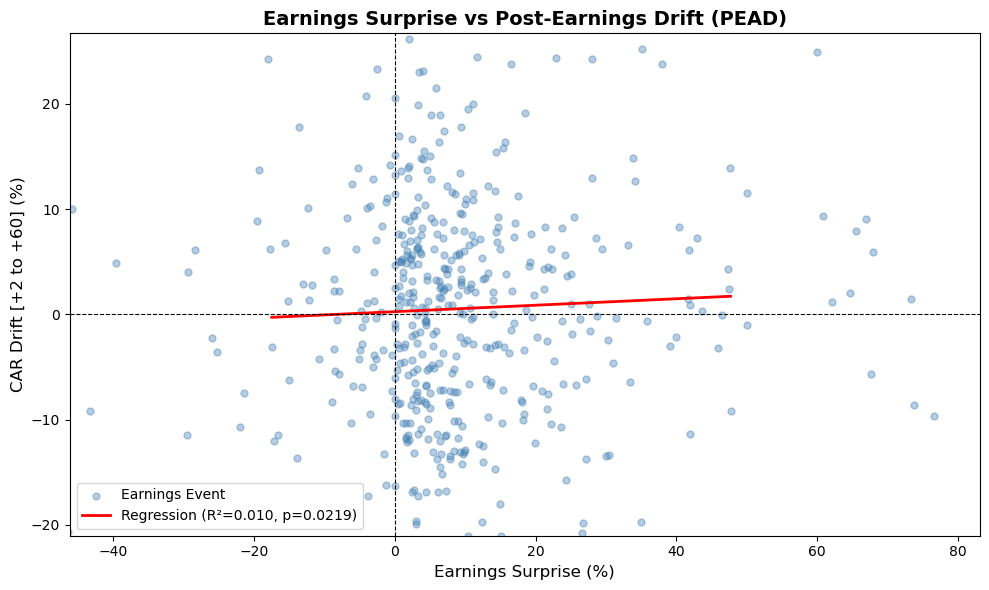

Chart 1 saved.


In [15]:
# ── CELL 12: SCATTER — SURPRISE vs POST-EARNINGS DRIFT ─────
# Theory:
# If PEAD exists, there should be a positive linear relationship
# between surprise_pct (x-axis) and car_drift (y-axis).
# We add a regression line to confirm the correlation.

fig, ax = plt.subplots(figsize=(10, 6))

sample = car_df.sample(min(500, len(car_df)), random_state=42)

ax.scatter(sample['surprise_pct'], sample['car_drift'] * 100,
           alpha=0.4, s=25, color='steelblue', label='Earnings Event')

# Regression line
m, b, r, p, se = stats.linregress(
    car_df['surprise_pct'].dropna(),
    car_df['car_drift'].dropna() * 100
)
x_line = np.linspace(car_df['surprise_pct'].quantile(0.05),
                     car_df['surprise_pct'].quantile(0.95), 100)
ax.plot(x_line, m * x_line + b, 'r-', linewidth=2,
        label=f'Regression (R²={r**2:.3f}, p={p:.4f})')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Earnings Surprise (%)', fontsize=12)
ax.set_ylabel(f'CAR Drift [+2 to +{HOLD_DAYS}] (%)', fontsize=12)
ax.set_title('Earnings Surprise vs Post-Earnings Drift (PEAD)', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xlim(car_df['surprise_pct'].quantile(0.02), car_df['surprise_pct'].quantile(0.98))
ax.set_ylim(car_df['car_drift'].quantile(0.02)*100, car_df['car_drift'].quantile(0.98)*100)
plt.tight_layout()
plt.savefig('output/scatter_surprise_vs_drift.png', dpi=150)
plt.show()
print("Chart 1 saved.")

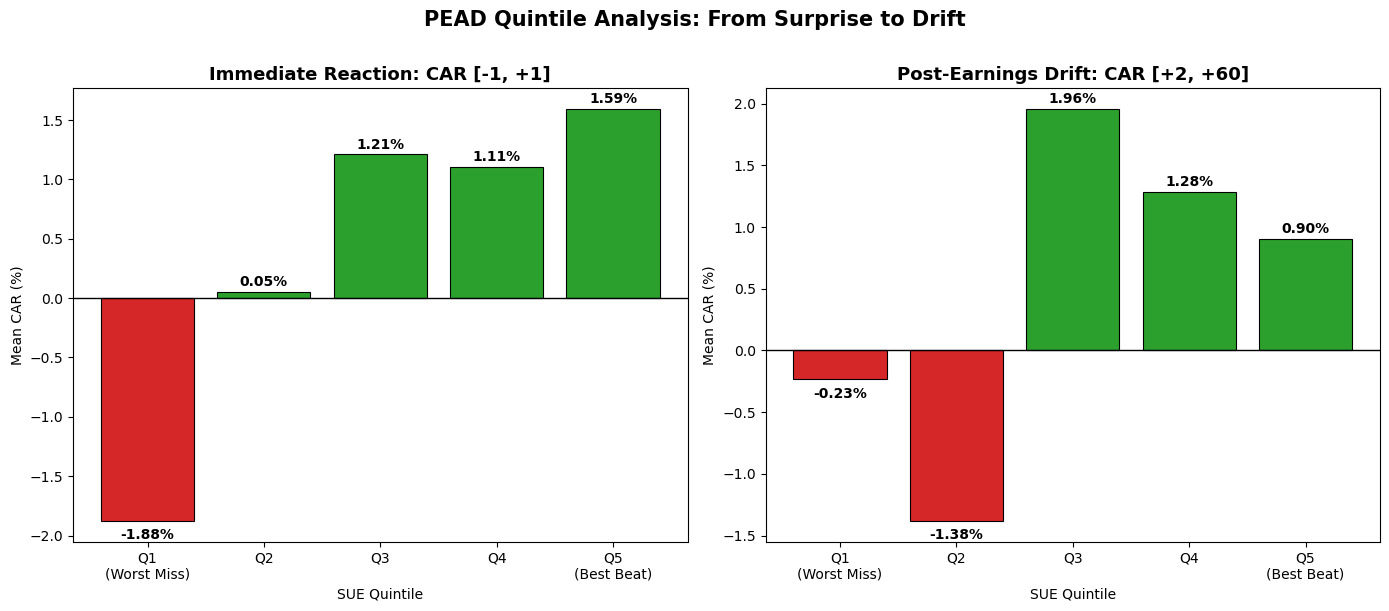

Chart 2 saved.


In [16]:

# ── CELL 13: BAR CHART — CAR BY SUE QUINTILE ───────────────
# Theory:
# If PEAD is real, the bar chart should show a monotonically
# increasing pattern from Q1 (negative CAR drift) to Q5 (positive).
# This is called the "quintile spread" — a classic academic test.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_imm   = ['#d62728' if v < 0 else '#2ca02c'
                 for v in quintile_stats['mean_car_imm_pct']]
colors_drift = ['#d62728' if v < 0 else '#2ca02c'
                 for v in quintile_stats['mean_car_drift_pct']]

# Panel A: Immediate reaction
axes[0].bar(quintile_stats['sue_quintile'],
            quintile_stats['mean_car_imm_pct'],
            color=colors_imm, edgecolor='black', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Immediate Reaction: CAR [-1, +1]', fontweight='bold', fontsize=13)
axes[0].set_xlabel('SUE Quintile')
axes[0].set_ylabel('Mean CAR (%)')
for i, v in enumerate(quintile_stats['mean_car_imm_pct']):
    axes[0].text(i, v + (0.05 if v >= 0 else -0.15),
                 f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')

# Panel B: Post-earnings drift
axes[1].bar(quintile_stats['sue_quintile'],
            quintile_stats['mean_car_drift_pct'],
            color=colors_drift, edgecolor='black', linewidth=0.8)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title(f'Post-Earnings Drift: CAR [+2, +{HOLD_DAYS}]',
                   fontweight='bold', fontsize=13)
axes[1].set_xlabel('SUE Quintile')
axes[1].set_ylabel('Mean CAR (%)')
for i, v in enumerate(quintile_stats['mean_car_drift_pct']):
    axes[1].text(i, v + (0.05 if v >= 0 else -0.15),
                 f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('PEAD Quintile Analysis: From Surprise to Drift',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/quintile_car_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

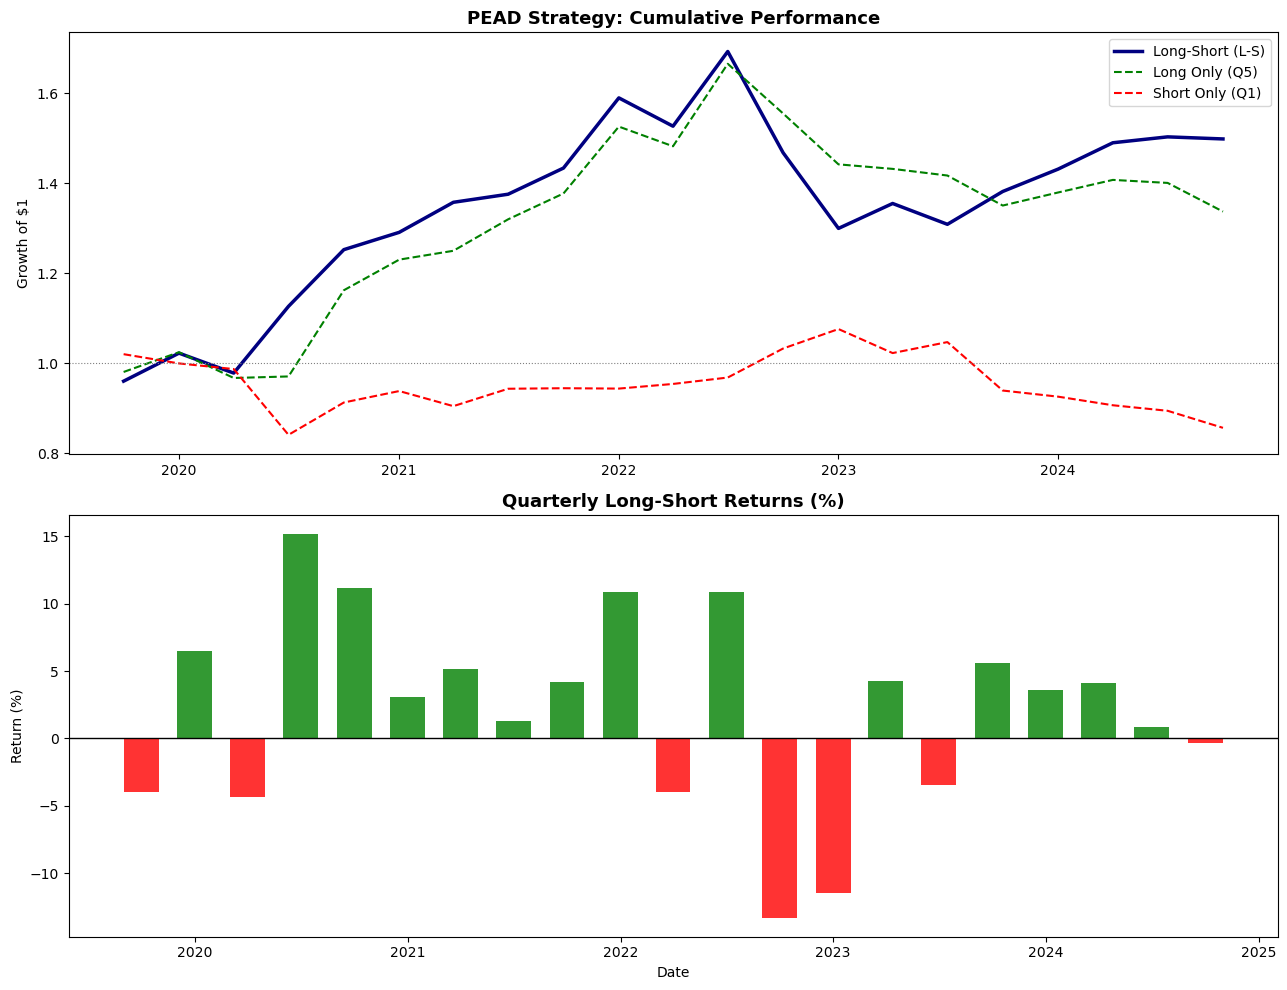

Chart 3 saved.


In [17]:
# ── CELL 14: CUMULATIVE L-S PORTFOLIO PERFORMANCE ──────────
# Theory:
# This is the equity curve of the strategy — it shows how
# $1 invested at the start compounds over time.
# A consistently upward-sloping curve = persistent edge.
# Drawdowns (falls) show periods when the strategy underperforms.

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# Panel A: Cumulative return
axes[0].plot(ls_df['period_dt'], ls_df['cum_ls_return'],
             color='navy', linewidth=2.5, label='Long-Short (L-S)')
axes[0].plot(ls_df['period_dt'], ls_df['cum_long_return'],
             color='green', linewidth=1.5, linestyle='--', label='Long Only (Q5)')
axes[0].plot(ls_df['period_dt'], ls_df['cum_short_return'],
             color='red', linewidth=1.5, linestyle='--', label='Short Only (Q1)')
axes[0].axhline(1, color='gray', linewidth=0.8, linestyle=':')
axes[0].set_title('PEAD Strategy: Cumulative Performance',
                   fontweight='bold', fontsize=13)
axes[0].set_ylabel('Growth of $1')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


# Panel B: Quarterly L-S returns as bar chart
colors_q = ['green' if r > 0 else 'red' for r in ls_df['ls_return']]
axes[1].bar(ls_df['period_dt'], ls_df['ls_return'] * 100,
            color=colors_q, alpha=0.8, width=60)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Quarterly Long-Short Returns (%)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Return (%)')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('output/ls_portfolio_performance.png', dpi=150)
plt.show()
print("Chart 3 saved.")

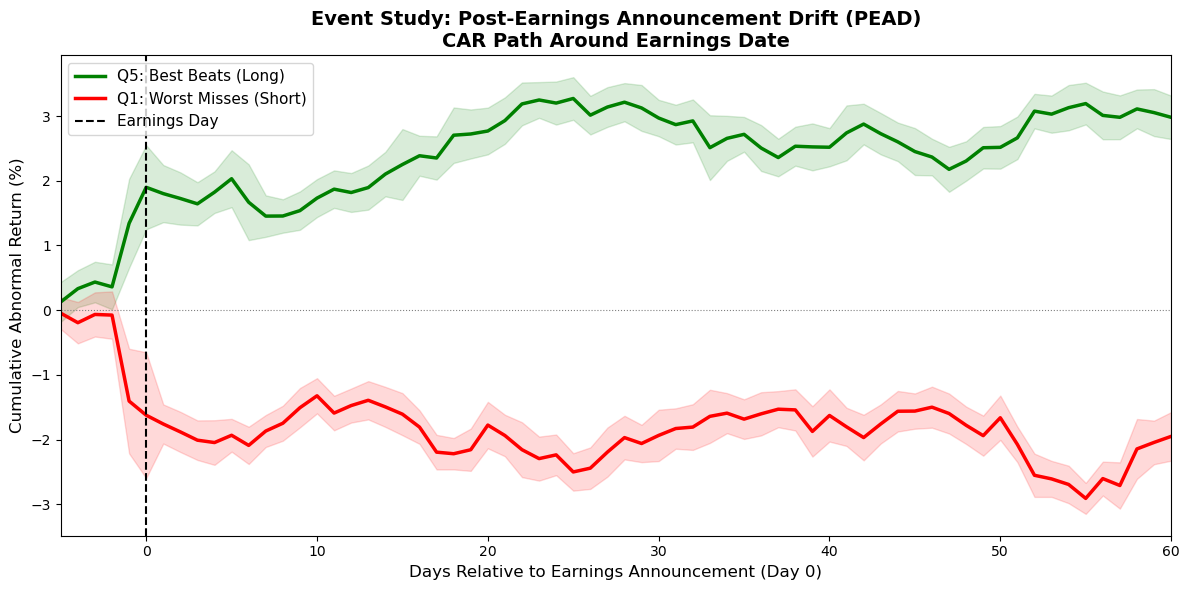

Chart 4 saved.


In [18]:
# ── CELL 15: DRIFT PATH — EVENT STUDY ──────────────────────
# Theory:
# An event study plots the AVERAGE cumulative abnormal return
# starting from N days before earnings (day -5) through to
# N days after (day +60), separately for top and bottom quintile.
# Classic "V-shape" or "split path" confirms PEAD visually.

event_window_pre  = 5
event_window_post = HOLD_DAYS

event_paths = {q: [] for q in ['Q1\n(Worst Miss)', 'Q5\n(Best Beat)']}

for _, row in car_df[car_df['sue_quintile'].isin(event_paths.keys())].iterrows():
    ticker   = row['ticker']
    ann_date = row['ann_date']
    quintile = row['sue_quintile']

    if ticker not in stock_returns.columns:
        continue

    idx = trading_calendar.searchsorted(ann_date)
    start = idx - event_window_pre
    end   = idx + event_window_post + 1

    if start < 0 or end > len(trading_calendar):
        continue

    try:
        s_ret = stock_returns[ticker].iloc[start:end].values
        m_ret = market_returns.iloc[start:end].values
        ab    = s_ret - m_ret
        if len(ab) == event_window_pre + event_window_post + 1:
            event_paths[quintile].append(ab)
    except:
        continue
        
        
fig, ax = plt.subplots(figsize=(12, 6))
days = np.arange(-event_window_pre, event_window_post + 1)

for quintile, color, label in [
    ('Q5\n(Best Beat)', 'green', 'Q5: Best Beats (Long)'),
    ('Q1\n(Worst Miss)', 'red',   'Q1: Worst Misses (Short)')
]:
    if not event_paths[quintile]:
        continue
    mat = np.array(event_paths[quintile])
    avg_ab   = mat.mean(axis=0)
    cum_car  = np.cumsum(avg_ab) * 100
    stderr   = mat.std(axis=0) / np.sqrt(len(mat)) * 100
    ax.plot(days, cum_car, color=color, linewidth=2.5, label=label)
    ax.fill_between(days, cum_car - 1.96*stderr,
                    cum_car + 1.96*stderr, alpha=0.15, color=color)

    
ax.axvline(0, color='black', linewidth=1.5, linestyle='--', label='Earnings Day')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('Days Relative to Earnings Announcement (Day 0)', fontsize=12)
ax.set_ylabel('Cumulative Abnormal Return (%)', fontsize=12)
ax.set_title('Event Study: Post-Earnings Announcement Drift (PEAD)\nCAR Path Around Earnings Date',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(-event_window_pre, event_window_post)
plt.tight_layout()
plt.savefig('output/event_study_pead_path.png', dpi=150)
plt.show()
print("Chart 4 saved.")


In [19]:
# ── CELL 16: SUMMARY REPORT ────────────────────────────────

print("\n" + "="*55)
print("       EARNINGS SURPRISE & PEAD STRATEGY REPORT")
print("="*55)

print(f"\n📊 DATA SUMMARY")
print(f"   Tickers analysed        : {len(TICKERS)}")
print(f"   Earnings events         : {len(car_df)}")
print(f"   Date range              : {START_DATE} → {END_DATE}")

print(f"\n📈 EARNINGS SURPRISE")
print(f"   Beat rate               : {beats/total*100:.1f}%")
print(f"   Avg surprise (beats)    : "
      f"+{earnings_df[earnings_df['surprise_pct']>0]['surprise_pct'].mean():.1f}%")
print(f"   Avg surprise (misses)   : "
      f"{earnings_df[earnings_df['surprise_pct']<0]['surprise_pct'].mean():.1f}%")

print(f"\n🔁 PEAD EVIDENCE")
q5_mean = quintile_stats[quintile_stats['sue_quintile']=='Q5\n(Best Beat)']['mean_car_drift_pct'].values
q1_mean = quintile_stats[quintile_stats['sue_quintile']=='Q1\n(Worst Miss)']['mean_car_drift_pct'].values
if len(q5_mean) and len(q1_mean):
    print(f"   Q5 (Best Beat) drift    : {q5_mean[0]:+.2f}%")
    print(f"   Q1 (Worst Miss) drift   : {q1_mean[0]:+.2f}%")
    print(f"   Q5−Q1 spread            : {q5_mean[0]-q1_mean[0]:+.2f}%")

print(f"\n💼 LONG-SHORT STRATEGY")
print(f"   Periods tested          : {len(ls_df)} quarters")
print(f"   Mean quarterly return   : {ls_df['ls_return'].mean()*100:+.2f}%")
print(f"   Annualised (×4)         : {ls_df['ls_return'].mean()*400:+.2f}%")
print(f"   Win rate                : {(ls_df['ls_return']>0).mean()*100:.1f}%")
print(f"   t-stat / p-value        : {t_stat:.2f} / {p_value:.4f}")
print(f"   Significant at 5%       : {'YES ✓' if p_value<0.05 else 'NO ✗'}")

print(f"\n📁 SAVED CHARTS")
print(f"   output/scatter_surprise_vs_drift.png")
print(f"   output/quintile_car_analysis.png")
print(f"   output/ls_portfolio_performance.png")
print(f"   output/event_study_pead_path.png")
print("="*55)


       EARNINGS SURPRISE & PEAD STRATEGY REPORT

📊 DATA SUMMARY
   Tickers analysed        : 25
   Earnings events         : 521
   Date range              : 2019-01-01 → 2024-12-31

📈 EARNINGS SURPRISE
   Beat rate               : 79.2%
   Avg surprise (beats)    : +16.3%
   Avg surprise (misses)   : -27.3%

🔁 PEAD EVIDENCE
   Q5 (Best Beat) drift    : +0.90%
   Q1 (Worst Miss) drift   : -0.23%
   Q5−Q1 spread            : +1.14%

💼 LONG-SHORT STRATEGY
   Periods tested          : 21 quarters
   Mean quarterly return   : +2.19%
   Annualised (×4)         : +8.77%
   Win rate                : 66.7%
   t-stat / p-value        : 1.40 / 0.1782
   Significant at 5%       : NO ✗

📁 SAVED CHARTS
   output/scatter_surprise_vs_drift.png
   output/quintile_car_analysis.png
   output/ls_portfolio_performance.png
   output/event_study_pead_path.png


In [2]:
import os
os.makedirs('output', exist_ok=True)
print("Output folder ready!")

Output folder ready!
